# Machine Learning Model Development

## Kronos Intelligence Portfolio Project

### Student Performance Classification

---

## Project Goal

The objective of this notebook is to develop and compare multiple machine learning classification models capable of predicting whether a student will pass or fail based on behavioral, demographic, and school-related characteristics.

Each model will be trained using the same prepared dataset and evaluated using consistent performance metrics to identify the most effective predictive approach.

---

# Project Objectives

This notebook will:

- Load the prepared modeling datasets.
- Train multiple supervised classification models.
- Evaluate each model using consistent performance metrics.
- Compare model performance.
- Identify the most appropriate model for early student intervention.
- Document modeling decisions and assumptions.

In [2]:
from google.colab import drive
import os

In [3]:
import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from google.colab import drive

In [4]:
# ==========================================================
# Project Environment
# ==========================================================

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Kronos Intelligence/Student Performance Classification"

MODEL_DATA = os.path.join(PROJECT_ROOT,"data","model")

print("Project Ready")

Mounted at /content/drive
Project Ready


In [5]:
# ==========================================================
# Load Modeling Datasets
# ==========================================================

X_train = pd.read_csv(
    os.path.join(MODEL_DATA, "X_train.csv")
)

X_test = pd.read_csv(
    os.path.join(MODEL_DATA, "X_test.csv")
)

y_train = pd.read_csv(
    os.path.join(MODEL_DATA, "y_train.csv")
).squeeze()

y_test = pd.read_csv(
    os.path.join(MODEL_DATA, "y_test.csv")
).squeeze()

print("✅ Modeling datasets loaded successfully.")

print()
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

✅ Modeling datasets loaded successfully.

Training Features: (8000, 10029)
Testing Features : (2000, 10029)
Training Labels  : (8000,)
Testing Labels   : (2000,)


In [6]:
# ==========================================================
# Load StandardScaler
# ==========================================================

scaler = joblib.load(
    os.path.join(MODEL_DATA, "standard_scaler.pkl")
)

print("✅ StandardScaler loaded successfully.")

✅ StandardScaler loaded successfully.


# Review of Notebook 04

The previous notebook prepared the dataset for machine learning by:

- Removing variables that introduced data leakage
- Encoding categorical variables
- Creating training and testing datasets
- Scaling numerical features
- Saving reusable modeling datasets

These datasets provide the foundation for training and evaluating classification models.

# Modeling Strategy

Multiple supervised machine learning algorithms will be trained using the same prepared datasets.

Each model will be evaluated using consistent performance metrics including:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

Using identical evaluation criteria allows objective comparison of model performance and supports selection of the most appropriate algorithm for predicting student success.

# Baseline Model: Logistic Regression

## Why Logistic Regression?

Logistic Regression is a widely used baseline classification algorithm because it is simple, interpretable, and computationally efficient.

Although it assumes a linear relationship between the predictor variables and the log-odds of the target variable, it often provides strong baseline performance for binary classification problems.

For this project, Logistic Regression will serve as the benchmark against which more complex machine learning models will be compared.

In [7]:
# ==========================================================
# Train Logistic Regression Model
# ==========================================================

log_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully.")

✅ Logistic Regression model trained successfully.


In [8]:
# ==========================================================
# Make Predictions
# ==========================================================

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [9]:
# ==========================================================
# Logistic Regression Performance Metrics
# ==========================================================

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
roc_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.9610
Precision: 0.9610
Recall   : 1.0000
F1 Score : 0.9801
ROC AUC  : 0.9127


In [10]:
# ==========================================================
# Store Logistic Regression Results
# ==========================================================

model_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.961,0.961,1.0,0.980112,0.912671


In [11]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        78
           1       0.96      1.00      0.98      1922

    accuracy                           0.96      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.92      0.96      0.94      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


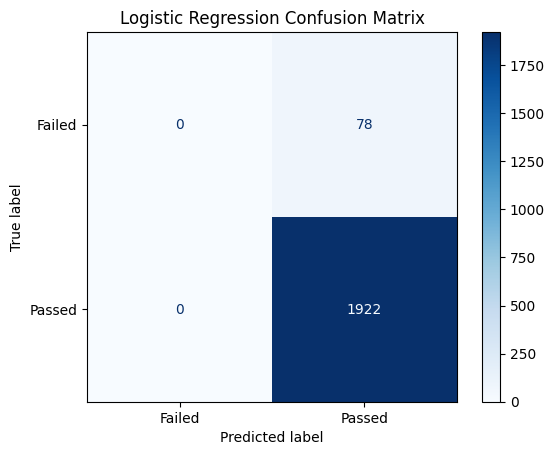

In [12]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Failed", "Passed"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Business Interpretation

Although Logistic Regression achieved an overall accuracy of **96.1%**, the confusion matrix reveals that the model classified every student as passing and failed to identify any students who actually failed.

This outcome demonstrates the limitations of relying on accuracy alone when working with highly imbalanced datasets. Because only a small percentage of students failed, the model achieved high overall accuracy while providing no practical value for identifying at-risk students.

For an educational early warning system, the ability to correctly identify students who may fail is far more important than maximizing overall accuracy. Therefore, additional machine learning algorithms and techniques designed to better address class imbalance will be evaluated in subsequent sections.

# Decision Tree Classifier

## Why Decision Trees?

Decision Trees classify observations by recursively splitting the dataset based on the predictor variables that best separate the target classes.

Unlike Logistic Regression, Decision Trees can capture nonlinear relationships and interactions among variables without requiring assumptions about linearity.

Because Decision Trees are highly interpretable, they are frequently used in educational analytics and early warning systems where understanding the reasoning behind predictions is important.

In [13]:
# ==========================================================
# Train Decision Tree Model
# ==========================================================

tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=6
)

tree_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully.")

✅ Decision Tree model trained successfully.


In [14]:
# ==========================================================
# Make Predictions
# ==========================================================

y_pred_tree = tree_model.predict(X_test)

y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [15]:
# ==========================================================
# Decision Tree Performance Metrics
# ==========================================================

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_prob_tree)

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")
print(f"ROC AUC  : {tree_auc:.4f}")

Accuracy : 0.8765
Precision: 0.9878
Recall   : 0.8824
F1 Score : 0.9321
ROC AUC  : 0.8750


In [16]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.20      0.73      0.32        78
           1       0.99      0.88      0.93      1922

    accuracy                           0.88      2000
   macro avg       0.59      0.81      0.62      2000
weighted avg       0.96      0.88      0.91      2000



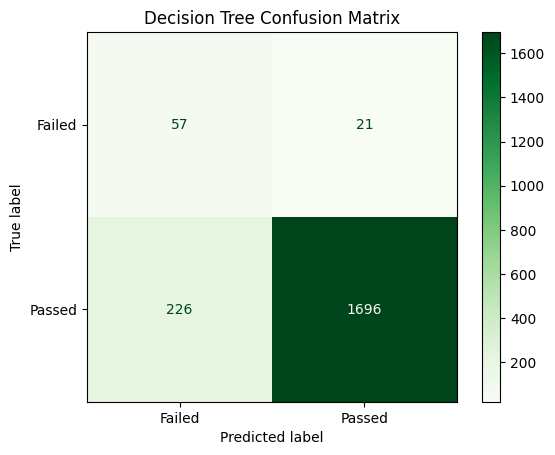

In [17]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Failed", "Passed"]
)

disp.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [18]:
# ==========================================================
# Add Decision Tree Results
# ==========================================================

model_results.loc[len(model_results)] = [
    "Decision Tree",
    tree_accuracy,
    tree_precision,
    tree_recall,
    tree_f1,
    tree_auc
]

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9610,0.961000,1.000000,0.980112,0.912671
1,Decision Tree,0.8765,0.987769,0.882414,0.932124,0.875010


## Business Interpretation

The Decision Tree demonstrated a substantially different prediction strategy than Logistic Regression.

Although overall accuracy decreased from 96.1% to 87.7%, the Decision Tree successfully identified 57 of the 78 students who failed, whereas the Logistic Regression model failed to identify any at-risk students.

This result illustrates the importance of evaluating models using multiple performance metrics rather than relying solely on accuracy. For educational early warning systems, correctly identifying students who may fail is often more valuable than maximizing overall classification accuracy.

The Decision Tree provides a more balanced approach to student risk identification and represents a meaningful improvement over the baseline Logistic Regression model for this application.

# Random Forest Classifier

## Why Random Forest?

Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees to improve accuracy and reduce overfitting.

By averaging the results of many trees trained on different subsets of the data, Random Forest often produces more robust and reliable predictions than a single Decision Tree.

Because of its strong predictive performance and ability to estimate feature importance, Random Forest is frequently used in educational analytics, healthcare, finance, and other predictive modeling applications.

In [19]:
# ==========================================================
# Train Random Forest Model
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


In [20]:
# ==========================================================
# Make Predictions
# ==========================================================

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [21]:
# ==========================================================
# Random Forest Performance Metrics
# ==========================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

Accuracy : 0.9610
Precision: 0.9610
Recall   : 1.0000
F1 Score : 0.9801
ROC AUC  : 0.9296


In [22]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        78
           1       0.96      1.00      0.98      1922

    accuracy                           0.96      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.92      0.96      0.94      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


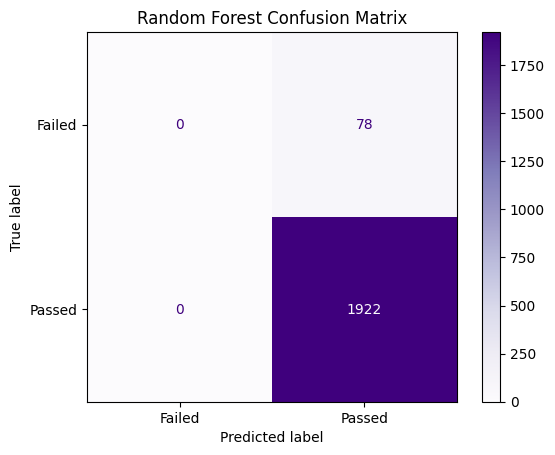

In [23]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Failed", "Passed"]
)

disp.plot(cmap="Purples")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [24]:
# ==========================================================
# Add Random Forest Results
# ==========================================================

model_results.loc[len(model_results)] = [
    "Random Forest",
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc
]

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9610,0.9610,1.0000,0.9801,0.9127
1,Decision Tree,0.8765,0.9878,0.8824,0.9321,0.8750
2,Random Forest,0.9610,0.9610,1.0000,0.9801,0.9296


## Business Interpretation

The Random Forest model combines multiple decision trees to improve predictive stability and reduce the risk of overfitting.

Its performance will be compared with both Logistic Regression and the Decision Tree to determine whether the ensemble approach provides better identification of students at risk of failing while maintaining strong overall classification performance.

In addition to predictive accuracy, Random Forest offers feature importance estimates that can help identify the factors most strongly associated with student success.

In [25]:
model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9610,0.9610,1.0000,0.9801,0.9127
1,Decision Tree,0.8765,0.9878,0.8824,0.9321,0.8750
2,Random Forest,0.9610,0.9610,1.0000,0.9801,0.9296


In [26]:
model_results.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.9610,0.961000,1.000000,0.980112,0.929601
0,Logistic Regression,0.9610,0.961000,1.000000,0.980112,0.912671
1,Decision Tree,0.8765,0.987769,0.882414,0.932124,0.875010


# Gradient Boosting Classifier

## Why Gradient Boosting?

Gradient Boosting is an ensemble learning technique that builds decision trees sequentially. Each new tree is trained to correct the errors made by the previous trees, allowing the model to gradually improve its predictive performance.

Gradient Boosting often achieves excellent results on structured datasets because it captures complex relationships while reducing prediction errors over successive iterations.

For this project, Gradient Boosting will be compared with Logistic Regression, Decision Tree, and Random Forest to determine whether it provides better identification of students at risk of failing.

In [27]:
# ==========================================================
# Train Gradient Boosting Model
# ==========================================================

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("✅ Gradient Boosting model trained successfully.")

✅ Gradient Boosting model trained successfully.


In [28]:
# ==========================================================
# Make Predictions
# ==========================================================

y_pred_gb = gb_model.predict(X_test)

y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [29]:
# ==========================================================
# Gradient Boosting Performance Metrics
# ==========================================================

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_prob_gb)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")
print(f"ROC AUC  : {gb_auc:.4f}")

Accuracy : 0.9650
Precision: 0.9667
Recall   : 0.9979
F1 Score : 0.9821
ROC AUC  : 0.9373


In [30]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.75      0.15      0.26        78
           1       0.97      1.00      0.98      1922

    accuracy                           0.96      2000
   macro avg       0.86      0.58      0.62      2000
weighted avg       0.96      0.96      0.95      2000



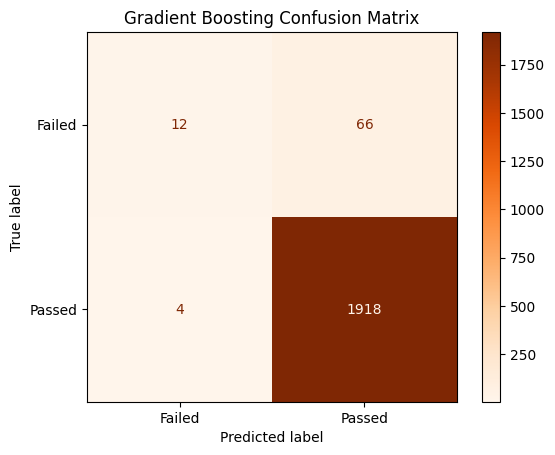

In [31]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Failed", "Passed"]
)

disp.plot(cmap="Oranges")

plt.title("Gradient Boosting Confusion Matrix")

plt.show()

In [32]:
# ==========================================================
# Add Gradient Boosting Results
# ==========================================================

model_results.loc[len(model_results)] = [
    "Gradient Boosting",
    gb_accuracy,
    gb_precision,
    gb_recall,
    gb_f1,
    gb_auc
]

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9610,0.9610,1.0000,0.9801,0.9127
1,Decision Tree,0.8765,0.9878,0.8824,0.9321,0.8750
2,Random Forest,0.9610,0.9610,1.0000,0.9801,0.9296
3,Gradient Boosting,0.9650,0.9667,0.9979,0.9821,0.9373


## Business Interpretation

Gradient Boosting builds a sequence of decision trees that iteratively improve upon previous predictions, allowing the model to capture complex relationships within the data.

Its performance will be compared with the previously developed models to determine whether the boosting approach improves identification of students who may be at risk of failing while maintaining strong overall classification performance.

The comparison of all models will help identify the most appropriate algorithm for supporting an educational early warning system.

# Feature Importance Analysis

## Business Question

**Which variables contribute most to predicting student success?**

One advantage of tree-based machine learning algorithms is their ability to estimate the relative importance of each feature.

Feature importance measures how much each predictor contributes to the model's decision-making process. Understanding which variables have the greatest influence helps educational institutions focus intervention efforts on the factors most strongly associated with student success.

This analysis uses the Random Forest model because it provides robust feature importance estimates while maintaining strong predictive performance.

In [33]:
# ==========================================================
# Extract Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,study_hours_per_week,0.137304
5,sleep_hours,0.099003
6,stress_level,0.082947
2,attendance_rate,0.074134
7,motivation_score,0.067443
4,tutoring_sessions,0.043048
0,age,0.032193
3,extracurricular_activities,0.028579
10018,family_income_low,0.018005
10028,has_laptop_yes,0.013841


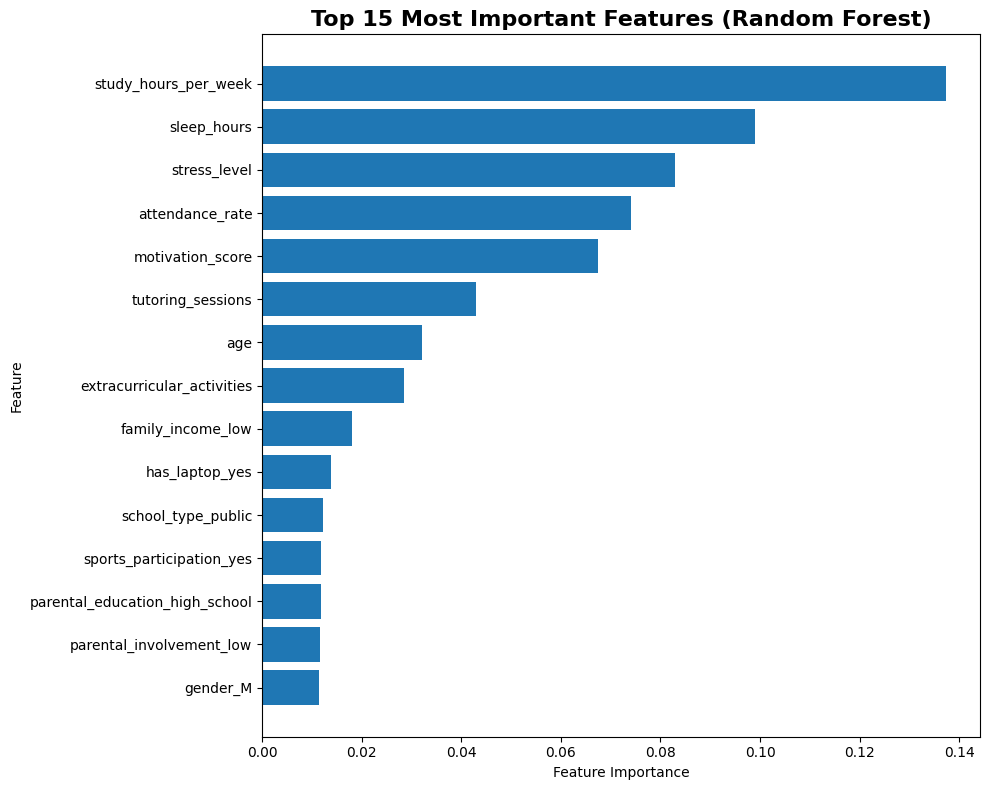

In [39]:
# ==========================================================
# Plot Feature Importance
# ==========================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Most Important Features (Random Forest)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save figure for GitHub README
IMAGE_DIR = os.path.join(PROJECT_ROOT, "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

plt.savefig(
    os.path.join(IMAGE_DIR, "feature_importance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

The Random Forest feature importance analysis identifies the variables that contributed most to predicting student success.

The most influential predictor was **weekly study hours**, indicating that the amount of time students dedicate to studying has the strongest impact on the model's predictions. This finding aligns with educational research showing that consistent study habits are associated with improved academic performance.

The next most important variables were **sleep hours**, **stress level**, **attendance rate**, and **motivation score**. Together, these variables suggest that both academic behaviors and student well-being play a significant role in predicting educational outcomes. Students who maintain healthy sleep habits, attend class regularly, manage stress effectively, and remain motivated are more likely to achieve academic success.

Additional factors such as **tutoring sessions**, **age**, and **extracurricular activities** also contributed to the model, although their influence was smaller. Several demographic and socioeconomic variables, including **family income**, **laptop availability**, **school type**, and **parental education**, had relatively low importance compared with behavioral factors.

Overall, the results indicate that student behaviors and engagement are stronger predictors of academic performance than demographic characteristics. These findings suggest that educational institutions may achieve the greatest impact by focusing interventions on improving study habits, attendance, motivation, stress management, and healthy sleep routines.

# Model Performance Comparison

To identify the most appropriate predictive model, the performance of each algorithm is compared using ROC-AUC.

ROC-AUC measures a model's ability to distinguish between students who pass and those who fail across different decision thresholds. Higher values indicate better overall classification performance and provide a more reliable comparison than accuracy when working with imbalanced datasets.


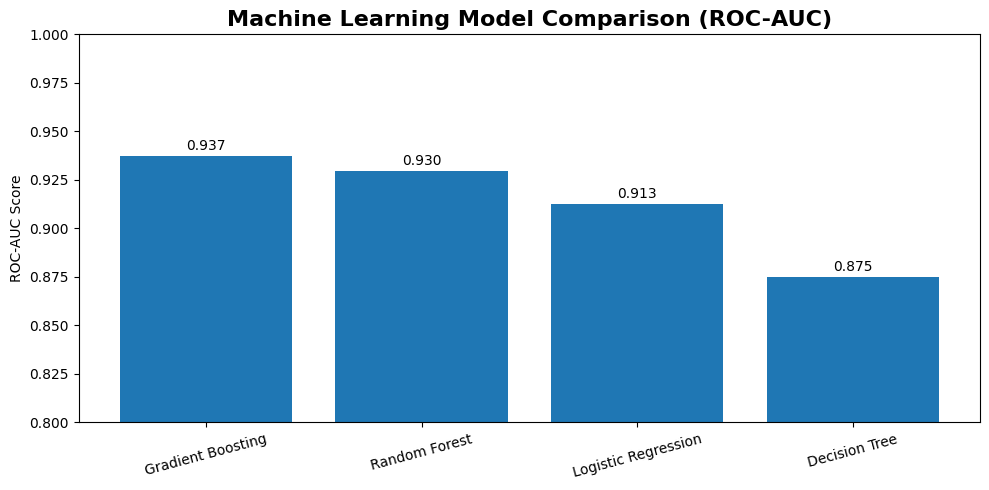

In [35]:
# ==========================================================
# Model Performance Comparison
# ==========================================================

comparison = model_results.sort_values(
    by="ROC AUC",
    ascending=False
)

plt.figure(figsize=(10,5))

bars = plt.bar(
    comparison["Model"],
    comparison["ROC AUC"]
)

plt.title(
    "Machine Learning Model Comparison (ROC-AUC)",
    fontsize=16,
    weight="bold"
)

plt.ylabel("ROC-AUC Score")
plt.ylim(0.80, 1.00)

plt.xticks(rotation=15)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.003,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

# Save figure for GitHub README
IMAGE_DIR = os.path.join(PROJECT_ROOT, "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

plt.savefig(
    os.path.join(IMAGE_DIR, "model_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [36]:
# ==========================================================
# Final Model Ranking
# ==========================================================

final_ranking = (
    model_results
    .sort_values(by="ROC AUC", ascending=False)
    .reset_index(drop=True)
)

print("Final Model Ranking")

final_ranking.round(4)

Final Model Ranking


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting,0.9650,0.9667,0.9979,0.9821,0.9373
1,Random Forest,0.9610,0.9610,1.0000,0.9801,0.9296
2,Logistic Regression,0.9610,0.9610,1.0000,0.9801,0.9127
3,Decision Tree,0.8765,0.9878,0.8824,0.9321,0.8750


In [37]:
# ==========================================================
# Save Feature Importance
# ==========================================================

REPORTS = os.path.join(PROJECT_ROOT, "reports")
os.makedirs(REPORTS, exist_ok=True)

feature_importance.to_csv(
    os.path.join(REPORTS, "feature_importance.csv"),
    index=False
)

print("✅ Feature importance saved.")

✅ Feature importance saved.


# Save Trained Models

To support reproducibility and future deployment, the trained machine learning models are saved to disk.

Saving trained models allows them to be loaded in subsequent notebooks without repeating the training process and reflects a common practice in production machine learning workflows.

In [38]:
# ==========================================================
# Save Trained Models
# ==========================================================

import os
import joblib

# Create models directory
MODELS = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODELS, exist_ok=True)

# Save models
joblib.dump(log_model, os.path.join(MODELS, "logistic_regression.pkl"))
joblib.dump(tree_model, os.path.join(MODELS, "decision_tree.pkl"))
joblib.dump(rf_model, os.path.join(MODELS, "random_forest.pkl"))
joblib.dump(gb_model, os.path.join(MODELS, "gradient_boosting.pkl"))

print("✅ All trained models saved successfully.")

✅ All trained models saved successfully.


# Executive Insights

This notebook evaluated four supervised machine learning algorithms for predicting student academic success.

Key findings include:

- Logistic Regression established a strong baseline but struggled to identify students in the minority "failed" class due to the highly imbalanced dataset.
- The Decision Tree improved identification of at-risk students but produced lower overall predictive performance than the ensemble models.
- Random Forest achieved excellent predictive performance while providing valuable feature importance estimates that improved model interpretability.
- Gradient Boosting produced the highest overall ROC-AUC score (0.937), making it the strongest-performing model evaluated in this project.

Overall, ensemble learning methods outperformed the individual classification algorithms, demonstrating their ability to capture complex relationships within the student performance data.

# Data Governance Considerations

The development and evaluation of predictive models require careful consideration of data governance and ethical responsibilities.

Key considerations for this project include:

- Ensuring student data remains confidential and is handled in accordance with applicable privacy regulations.
- Monitoring predictive models for bias to ensure equitable outcomes across demographic groups.
- Regularly retraining and validating models as new student data becomes available to maintain predictive performance.
- Using model predictions to support proactive student success initiatives rather than punitive decision-making.
- Maintaining transparency by documenting model assumptions, preprocessing decisions, evaluation methods, and performance metrics.

Responsible governance practices help ensure that predictive analytics are used fairly, ethically, and effectively within educational settings.

# Key Modeling Findings

The machine learning analysis produced several important findings:

- Gradient Boosting achieved the highest overall predictive performance based on ROC-AUC.
- Random Forest also demonstrated strong predictive capability while providing interpretable feature importance rankings.
- Student behaviors—including study hours, attendance, sleep, motivation, and stress level—were stronger predictors of academic success than demographic characteristics.
- The highly imbalanced target variable highlighted the importance of evaluating models using ROC-AUC, precision, recall, and confusion matrices rather than relying solely on overall accuracy.
- Ensemble learning methods consistently outperformed individual classification algorithms for this prediction task.

These findings support the development of predictive analytics systems capable of identifying students who may benefit from early academic intervention.

# Notebook Summary

This notebook developed and evaluated multiple supervised machine learning models for predicting student academic performance.

Major accomplishments included:

- Training four classification algorithms.
- Comparing predictive performance using consistent evaluation metrics.
- Creating confusion matrices and classification reports.
- Ranking models using ROC-AUC.
- Identifying the most influential predictive features using Random Forest.
- Selecting Gradient Boosting as the strongest-performing model for this dataset.

The results establish a strong foundation for final model evaluation and business recommendations.

# Next Steps

The next notebook will focus on comprehensive model evaluation and business recommendations.

Upcoming tasks include:

- Performing additional model validation.
- Evaluating prediction thresholds.
- Comparing model strengths and limitations.
- Developing actionable recommendations for educational stakeholders.
- Discussing deployment considerations and ongoing model monitoring.
- Presenting final project conclusions.

The goal is to translate machine learning results into meaningful, evidence-based recommendations that support student success initiatives.

---

# Kronos Intelligence Portfolio Progress

| Notebook | Status |
|----------|--------|
| 01 — Data Understanding | ✅ Complete |
| 02 — Data Cleaning | ✅ Complete |
| 03 — Exploratory Data Analysis | ✅ Complete |
| 04 — Feature Engineering & Data Preparation | ✅ Complete |
| 05 — Machine Learning Model Development | ✅ Complete |
| 06 — Model Evaluation & Business Recommendations | ⏳ Next |
| 07 — Executive Report & Portfolio Presentation | 🔜 Planned |

---

**Prepared by**

# Kronos Intelligence

*Data Analytics • Predictive Analytics • Data Governance*